# Finding the best method for differentiating your data

With the number of methods in this repo, it is fair to wonder which will work best on your noisy data. We have implemented a routine to run `optimize` over (almost) all PyNumDiff differentiation methods and let you know which method and parameters settings achieved the lowest cost.

Cost is either

1. RMSE against the true derivative if given or
2. $L$ if no true derivative is known.

> $L$ balances the faithfulness and smoothness of the derivative estimate:
> $$L(\Phi) = \sigma_\text{MAD} \sqrt{\frac{2}{N}\sum\text{Huber}\bigg( \frac{\text{trapz}(\mathbf{\hat{\dot{x}}}(\Phi)) + c - \mathbf{y}}{\sigma_\text{MAD}}, M \bigg)} + \gamma \bigg(\text{TV}\big(\mathbf{\hat{\dot{x}}}(\Phi)\big)\bigg)$$
> where $\Phi$ are the hyperparameter settings of a differentiation method, $\mathbf{\hat{\dot{x}}}(\Phi)$ is an estimate of the derivative, the left term is a generalization of $\text{RMSE}$ that uses the Huber loss, $\sigma_\text{MAD}$ is a robust scatter measure (median absolute deviation), $M$ is a robustness parameter in units of $\sigma_\text{MAD}$ (often set to 2 or 3 so the vast majority of inliers are measured with RMSE), $\text{trapz}$ performs trapezoidal integration, $c$ corrects for a lost constant of integration (outlier-robustly), $\mathbf{y}$ is noisy data, $\gamma$ is a hyper-parameter, and $TV$ is the total variation:
> $$\text{TV}(\mathbf{\hat{\dot{x}}}) = \frac{1}{m}\left\lVert\mathbf{\hat{\dot{x}}}_{0:m-1}-\mathbf{\hat{\dot{x}}}_{1:m}\right\rVert_{1}$$
> A reasonable value of $\gamma$ can be estimated given a cutoff frequency (estimated by counting peaks per second in the data or by looking at power spectrum and choosing a cutoff), $f$, as
> $$\gamma = \exp(-1.6 \log(f) -0.71\log(\Delta t) - 5.1)$$
> See [this paper](https://ieeexplore.ieee.org/document/9241009) for more detail.

In [1]:
import os, sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path) # local import

from pynumdiff.optimize import suggest_method
from pynumdiff.utils import evaluate
from pynumdiff.utils.simulate import sine, triangle, pop_dyn, linear_autonomous,\
	pi_cruise_control, lorenz_x

## Simulate some data

In [2]:
# noise is generated using np.random, e.g. np.random.normal, np.random.uniform, np.random.poisson
# noise_type and noise_parameters should be compatible with np.random functions 
noise_type = 'normal'
noise_parameters = [0, 0.1]

# time step and time series length
dt = 0.01 # sampling time step
duration = 4 # sec
problem = pi_cruise_control

x, x_truth, dxdt_truth = problem(duration, noise_parameters=noise_parameters, dt=dt)

## Usage of the best method metamethod with known truth

In [3]:
method, opt_params = suggest_method(x, dt, dxdt_truth=dxdt_truth)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:54<00:00,  3.93s/it]


  7%|▋         | 1/14 [00:04<00:55,  4.25s/it]

 14%|█▍        | 2/14 [00:10<01:07,  5.65s/it]

 21%|██▏       | 3/14 [00:21<01:28,  8.05s/it]

 29%|██▊       | 4/14 [00:29<01:17,  7.74s/it]

...

 79%|███████▊  | 11/14 [01:44<00:42, 14.29s/it]

 86%|████████▌ | 12/14 [02:15<00:38, 19.47s/it]

 93%|█████████▎| 13/14 [03:16<00:31, 31.84s/it]

100%|██████████| 14/14 [04:01<00:00, 35.89s/it]

100%|██████████| 14/14 [04:01<00:00, 17.25s/it]

Suggested method: rbfdiff with params: {'sigma': np.float64(0.11398925781249991), 'lmbd': np.float64(0.11673339843749997)}


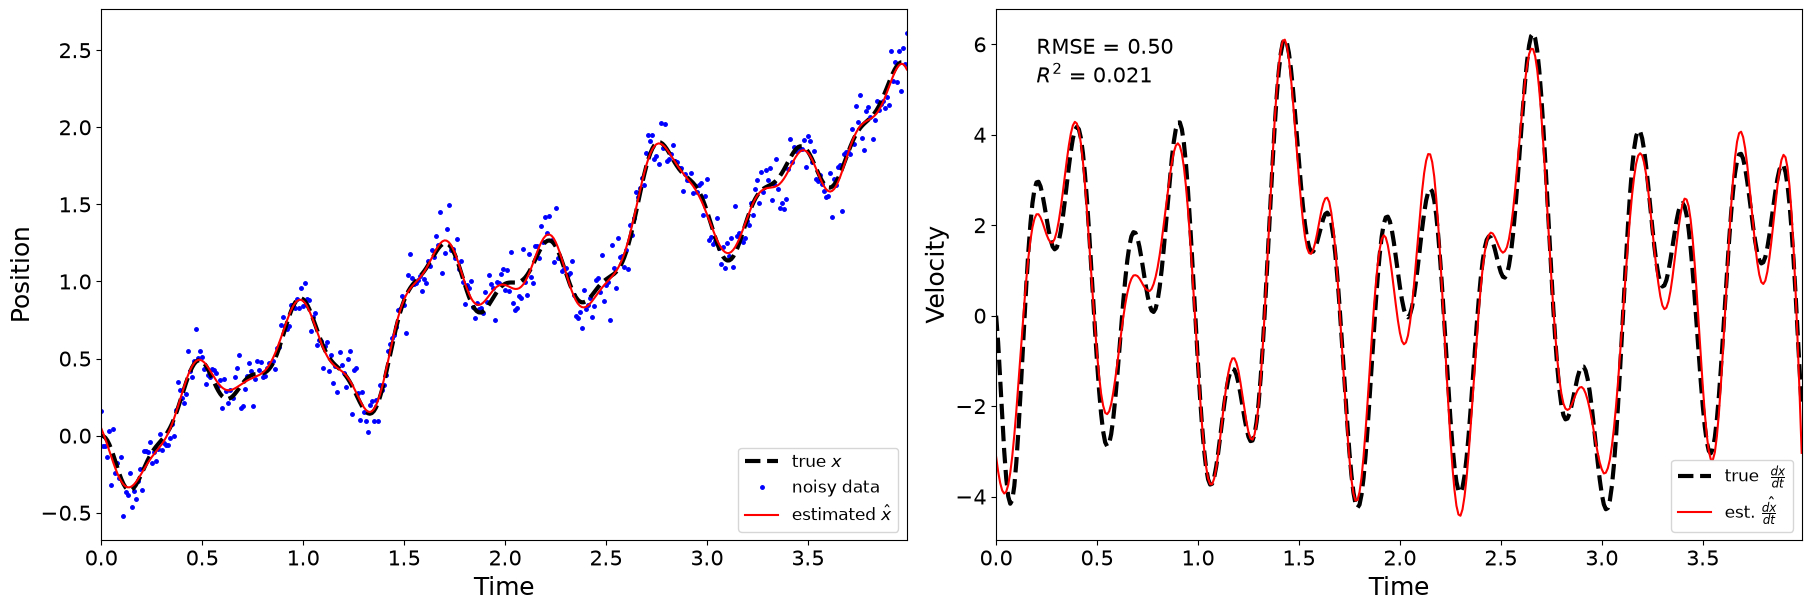

In [4]:
print('Suggested method:', method.__name__, 'with params:', opt_params)
x_hat, dxdt_hat = method(x, dt, **opt_params)
evaluate.plot(x, dt, x_hat, dxdt_hat, x_truth, dxdt_truth);

## Usage of the best method metamethod *without* known truth

In [5]:
method, opt_params = suggest_method(x, dt, bandlimit=3)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:58<00:00,  4.18s/it]


  7%|▋         | 1/14 [00:04<00:58,  4.46s/it]

 14%|█▍        | 2/14 [00:11<01:15,  6.26s/it]

 21%|██▏       | 3/14 [00:23<01:35,  8.64s/it]

 29%|██▊       | 4/14 [00:32<01:28,  8.80s/it]

...

 79%|███████▊  | 11/14 [01:49<00:42, 14.29s/it]

 86%|████████▌ | 12/14 [02:16<00:36, 18.39s/it]

 93%|█████████▎| 13/14 [03:24<00:33, 33.29s/it]

100%|██████████| 14/14 [04:13<00:00, 38.11s/it]

100%|██████████| 14/14 [04:13<00:00, 18.12s/it]

Suggested method: rtsdiff with params: {'log_qr_ratio': np.float64(4.365234375), 'forwardbackward': False, 'order': 1}


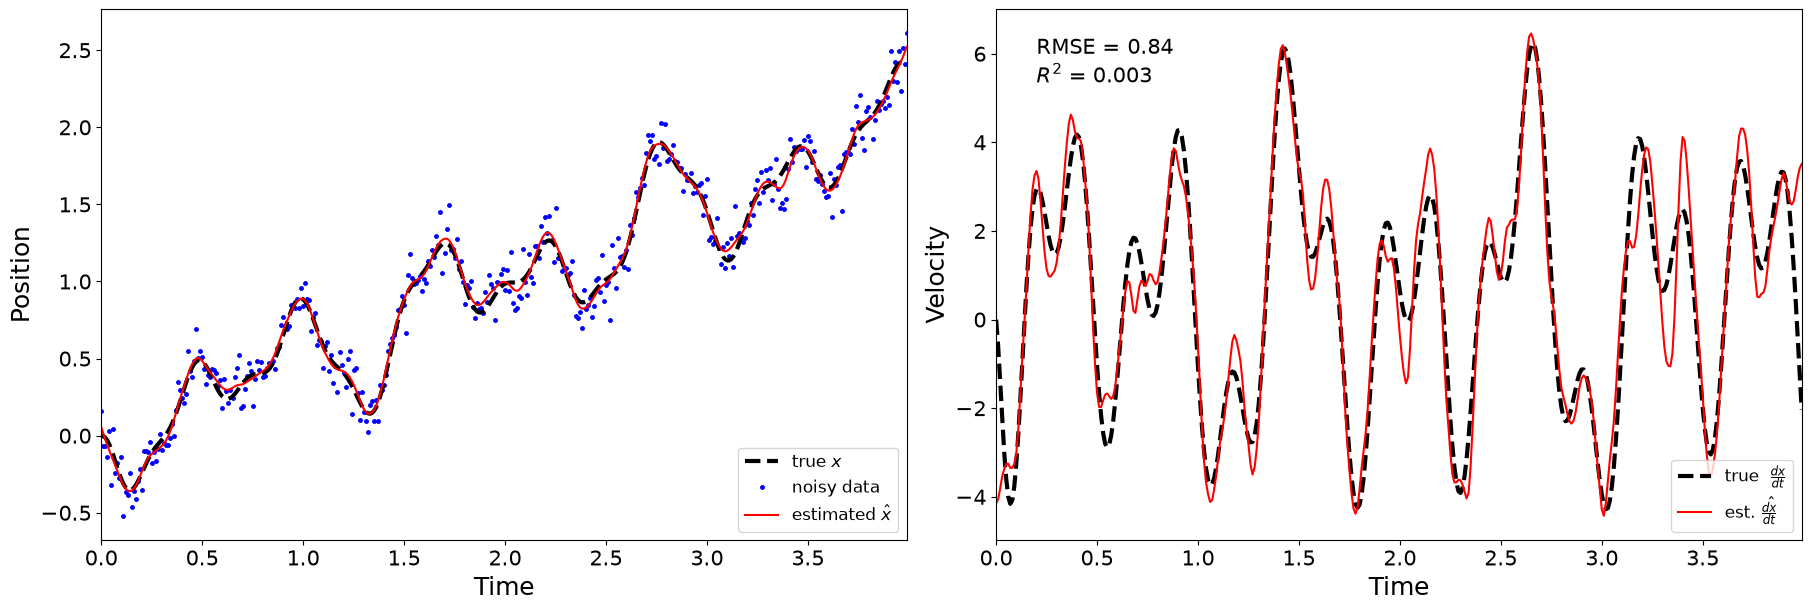

In [6]:
print('Suggested method:', method.__name__, 'with params:', opt_params)
x_hat, dxdt_hat = method(x, dt, **opt_params)
evaluate.plot(x, dt, x_hat, dxdt_hat, x_truth, dxdt_truth);